In [13]:
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import copy
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import matplotlib.pyplot as plt

In [3]:
def extract_features(item):
    """
    Convert one simulated SNP dataset item into a fixed-length feature vector.
    
    item should contain:
      - item["X"]: SNP matrix of shape (n_samples, num_snps)
      - item["theta"]
      - item["metadata"]
    """
    G = item["X"]   # shape: (n_samples, num_snps)
    n, s = G.shape
    
    theta = item.get("theta", np.nan)
    seq_len = item.get("metadata", {}).get("sequence_length", np.nan)
    
    # Handle edge case: zero SNPs
    if s == 0:
        return {
            "n_samples": n,
            "num_snps": 0,
            "snp_density": 0.0,
            "theta": theta,
            "sequence_length": seq_len,
            "mean_af": 0.0,
            "std_af": 0.0,
            "min_af": 0.0,
            "max_af": 0.0,
            "mean_heterozygosity": 0.0,
            "std_heterozygosity": 0.0,
            "singleton_prop": 0.0,
            "doubleton_prop": 0.0,
            "mean_minor_ac": 0.0,
            "var_minor_ac": 0.0,
            "mean_pairwise_diff": 0.0,
        }
    
    # Derived allele frequency per SNP
    allele_counts = G.sum(axis=0)                 # shape: (num_snps,)
    af = allele_counts / n                        # allele frequency
    minor_ac = np.minimum(allele_counts, n - allele_counts)
    
    # Per-site heterozygosity proxy
    heterozygosity = 2 * af * (1 - af)
    
    singleton_prop = np.mean((allele_counts == 1) | (allele_counts == n - 1))
    doubleton_prop = np.mean((allele_counts == 2) | (allele_counts == n - 2))
    
    # Mean pairwise difference proxy:
    # For a biallelic site, expected pairwise difference = 2p(1-p)
    mean_pairwise_diff = np.sum(heterozygosity)
    
    return {
        "n_samples": n,
        "num_snps": s,
        "snp_density": s / seq_len if seq_len and seq_len > 0 else np.nan,
        "theta": theta,
        "sequence_length": seq_len,
        "mean_af": np.mean(af),
        "std_af": np.std(af),
        "min_af": np.min(af),
        "max_af": np.max(af),
        "mean_heterozygosity": np.mean(heterozygosity),
        "std_heterozygosity": np.std(heterozygosity),
        "singleton_prop": singleton_prop,
        "doubleton_prop": doubleton_prop,
        "mean_minor_ac": np.mean(minor_ac),
        "var_minor_ac": np.var(minor_ac),
        "mean_pairwise_diff": mean_pairwise_diff,
    }

In [4]:
with open("simulated_snp_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

# Reuse your extract_features(item)
rows = [extract_features(item) for item in dataset]
X_df = pd.DataFrame(rows).fillna(0)
y = np.array([item["alpha"] for item in dataset], dtype=np.float32)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_df, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(14450, 16) (2550, 16) (3000, 16)


In [11]:
class SummaryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = SummaryDataset(X_train_scaled, y_train)
val_ds = SummaryDataset(X_val_scaled, y_val)
test_ds = SummaryDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [7]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
def evaluate_model(model, loader, device):
    model.eval()
    ys, preds = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            ys.append(y_batch.cpu().numpy())
            preds.append(pred.cpu().numpy())

    y_true = np.vstack(ys).ravel()
    y_pred = np.vstack(preds).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "y_true": y_true,
        "y_pred": y_pred
    }


def train_mlp(model, train_loader, val_loader, device, lr=1e-3, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_rmse = float("inf")
    best_state = None

    train_losses = []
    val_rmses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(X_batch)

        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = evaluate_model(model, val_loader, device)

        train_losses.append(train_loss)
        val_rmses.append(val_metrics["rmse"])

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val RMSE: {val_metrics['rmse']:.6f} | "
            f"Val Corr: {val_metrics['corr']:.4f}"
        )

        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return train_losses, val_rmses

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = MLPRegressor(input_dim=X_train_scaled.shape[1]).to(device)
train_losses, val_rmses = train_mlp(
    model, train_loader, val_loader, device, lr=1e-3, epochs=50
)

test_metrics = evaluate_model(model, test_loader, device)
print("\nMLP Test Performance")
print(test_metrics["rmse"], test_metrics["mae"], test_metrics["r2"], test_metrics["corr"])

cuda
Epoch 001 | Train Loss: 0.003400 | Val RMSE: 0.016773 | Val Corr: 0.0760
Epoch 002 | Train Loss: 0.000596 | Val RMSE: 0.013911 | Val Corr: 0.4029
Epoch 003 | Train Loss: 0.000323 | Val RMSE: 0.013319 | Val Corr: 0.5001
Epoch 004 | Train Loss: 0.000232 | Val RMSE: 0.012588 | Val Corr: 0.5320
Epoch 005 | Train Loss: 0.000193 | Val RMSE: 0.012225 | Val Corr: 0.5486
Epoch 006 | Train Loss: 0.000174 | Val RMSE: 0.012156 | Val Corr: 0.5533
Epoch 007 | Train Loss: 0.000169 | Val RMSE: 0.012231 | Val Corr: 0.5555
Epoch 008 | Train Loss: 0.000161 | Val RMSE: 0.012166 | Val Corr: 0.5585
Epoch 009 | Train Loss: 0.000158 | Val RMSE: 0.012224 | Val Corr: 0.5594
Epoch 010 | Train Loss: 0.000157 | Val RMSE: 0.012106 | Val Corr: 0.5583
Epoch 011 | Train Loss: 0.000155 | Val RMSE: 0.012161 | Val Corr: 0.5601
Epoch 012 | Train Loss: 0.000155 | Val RMSE: 0.012124 | Val Corr: 0.5597
Epoch 013 | Train Loss: 0.000153 | Val RMSE: 0.012072 | Val Corr: 0.5613
Epoch 014 | Train Loss: 0.000153 | Val RMSE: 0

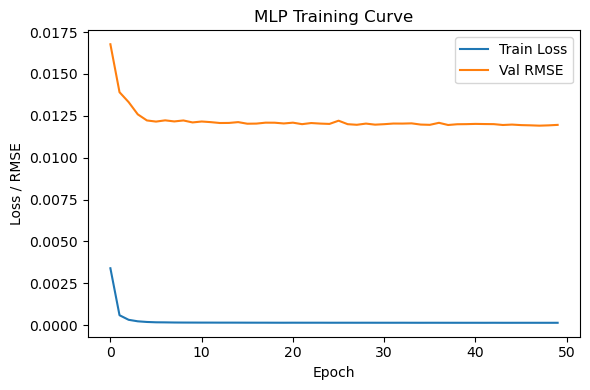

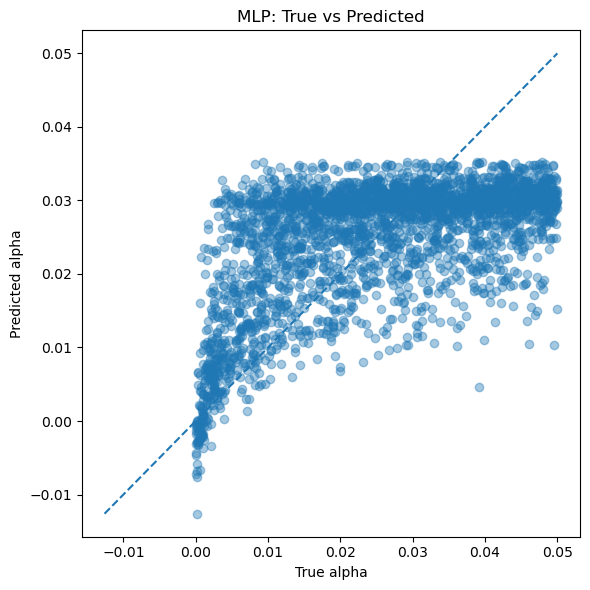

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_rmses, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("Loss / RMSE")
plt.title("MLP Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(test_metrics["y_true"], test_metrics["y_pred"], alpha=0.4)
mn = min(test_metrics["y_true"].min(), test_metrics["y_pred"].min())
mx = max(test_metrics["y_true"].max(), test_metrics["y_pred"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("True alpha")
plt.ylabel("Predicted alpha")
plt.title("MLP: True vs Predicted")
plt.tight_layout()
plt.show()